
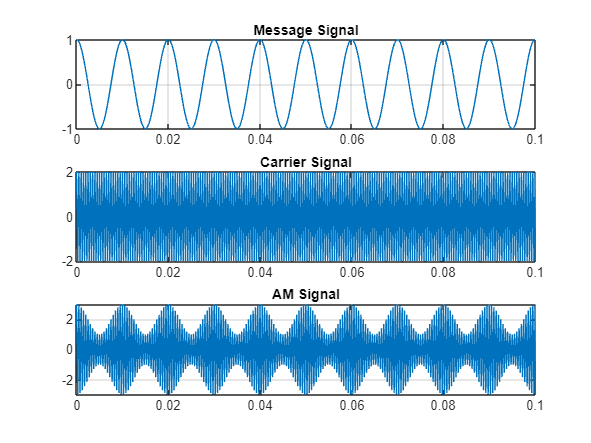

In [1]:
clc;
clear;
close all;

fs = 8000;
t = 0:1/fs:0.1;

Am = 1;
Ac = 2;

fm = 100;
fc = 2000;

m = Am*cos(2*pi*fm*t);
c = Ac*cos(2*pi*fc*t);

mu = Am/Ac;

s = Ac*(1 + mu*cos(2*pi*fm*t)).*cos(2*pi*fc*t);

figure;
subplot(3,1,1)
plot(t,m)
title('Message Signal')
grid on

subplot(3,1,2)
plot(t,c)
title('Carrier Signal')
grid on

subplot(3,1,3)
plot(t,s)
title('AM Signal')
grid on
hold off


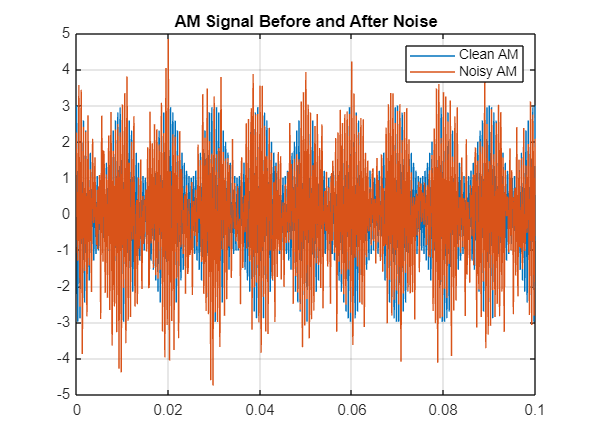

In [2]:
noise = 0.8*randn(size(t)); % AWGN
r = s + noise;

figure;
plot(t, s);
hold on;
plot(t, r);
legend('Clean AM','Noisy AM');
title('AM Signal Before and After Noise')
grid on


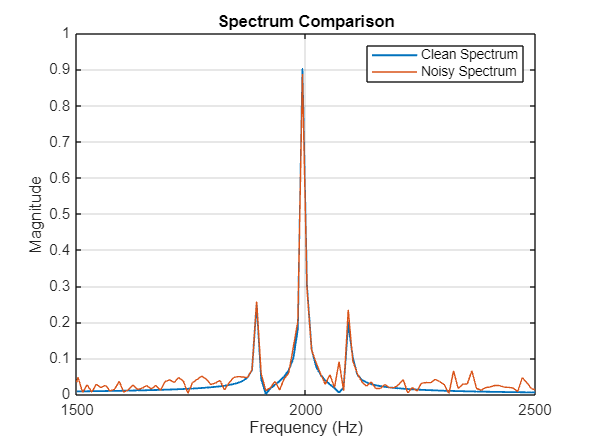

In [3]:
%% FFT Analysis

N = length(t);

f = (-N/2:N/2-1)*(fs/N);

S = abs(fftshift(fft(s)))/N;
R = abs(fftshift(fft(r)))/N;

figure('Name','FFT Comparison')

plot(f,S,'LineWidth',1.2)
hold on
plot(f,R)

xlim([1500 2500])

title('Spectrum Comparison')
xlabel('Frequency (Hz)')
ylabel('Magnitude')

legend('Clean Spectrum','Noisy Spectrum')

grid on


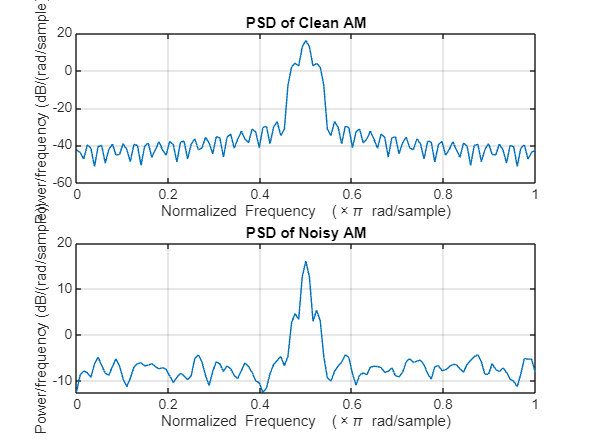

In [4]:
%% Power Spectral Density

figure('Name','PSD Comparison')

subplot(2,1,1)

pwelch(s)

title('PSD of Clean AM')

subplot(2,1,2)

pwelch(r)

title('PSD of Noisy AM')


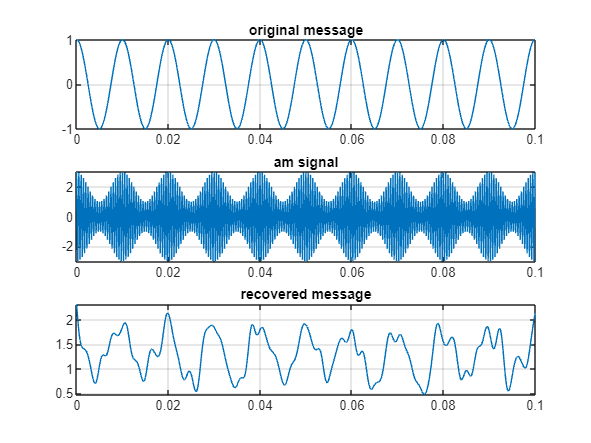

In [5]:
env = abs(r);
[b,a] = butter(4, 400/(fs/2));
recovered = filtfilt(b, a, env);

figure;
subplot(3, 1, 1)
plot(t, m);
title("original message");
grid on

subplot(3, 1, 2)
plot(t,s)
title("am signal")
grid on

subplot(3, 1, 3)
plot(t, recovered)
title("recovered message")
grid on


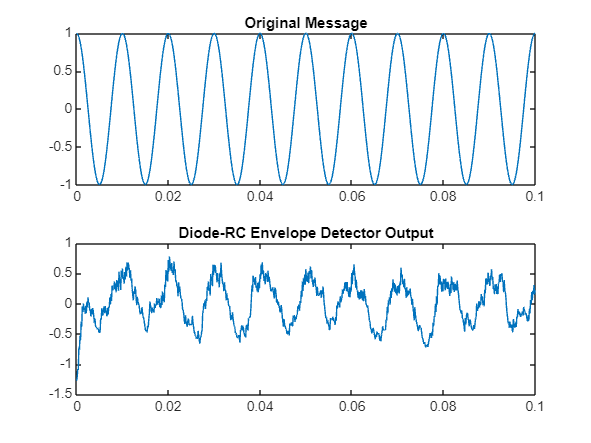

In [6]:
% Envelope detector approximation
rectified = abs(r);

% RC low-pass filter
RC = 0.001;
alpha = 1/(1 + fs*RC);

env = zeros(size(rectified));

for i = 2:length(rectified)
    env(i) = alpha*rectified(i) + (1-alpha)*env(i-1);
end

% Remove DC
env = env - mean(env);

figure;

subplot(2,1,1);
plot(t,m);
title('Original Message');

subplot(2,1,2);
plot(t,env);
title('Diode-RC Envelope Detector Output');


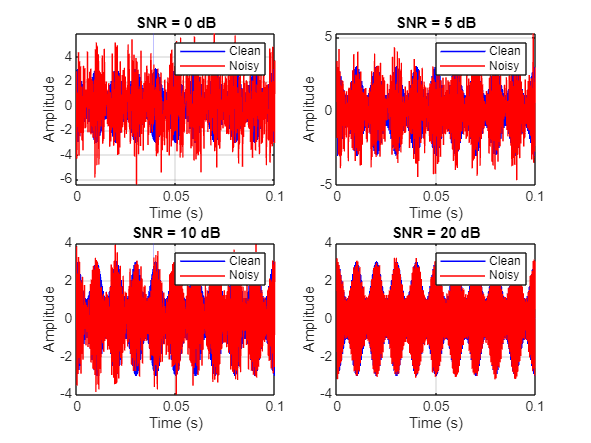

In [7]:

%% Effect of Different SNR Values

snr_values = [0 5 10 20];

figure('Name','SNR Comparison')

for i = 1:length(snr_values)

    r = awgn(s,snr_values(i),'measured');

    subplot(2,2,i)

    plot(t,s,'b','LineWidth',1)

    hold on

    plot(t,r,'r')

    title(['SNR = ',num2str(snr_values(i)),' dB'])

    xlabel('Time (s)')

    ylabel('Amplitude')

    legend('Clean','Noisy')

    grid on

end